# 07 Experiment Tracking with MLflow

In the previous notebooks, we trained multiple machine learning models, compared their performance, saved evaluation metrics, predictions, and model artifacts manually.

In this notebook, we introduce MLflow as a local experiment tracking tool. Rather than changing the model itself, the goal is to organize model development so experiments can be compared, reproduced, and inspected more efficiently.

## 1. Why Experiment Tracking Matters

Machine learning development is highly iterative. During a project we experiment with different features, preprocessing steps, algorithms, hyperparameters, and evaluation strategies.

Without structured experiment tracking, it quickly becomes difficult to answer questions such as:

- Which code produced this model?
- Which hyperparameters were used?
- Which evaluation metrics did the model achieve?
- Where are the predictions, plots, and saved model?
- Can the experiment be reproduced later?

MLflow provides a lightweight framework for recording this information automatically, making experiments easier to compare and reproduce.

## 2. What We Track in This Notebook

We log the selected XGBoost model from the previous notebook together with its associated experiment information.

The tracked artifacts include:

- model hyperparameters
- classification metrics
- prediction outputs
- confusion matrix
- trained model artifact
- experiment metadata

This allows future experiments to be compared consistently while keeping all relevant information in a single tracking system.

In [1]:
from pathlib import Path
from datetime import datetime

import joblib
import matplotlib.pyplot as plt
import mlflow
import mlflow.xgboost
from mlflow.tracking import MlflowClient
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    brier_score_loss,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from xgboost import XGBClassifier

/home/patri/.venvs/ads_II/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def find_project_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "data").exists() and (path / "notebooks").exists():
            return path
    raise FileNotFoundError("Could not find project root. Please run this notebook inside the project repository.")

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports" / "model_results"
MODELS_DIR = PROJECT_ROOT / "models"
MLRUNS_DIR = PROJECT_ROOT / "mlruns"
MLFLOW_DB = PROJECT_ROOT / "mlflow.db"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
MLRUNS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"MLflow artifact directory: {MLRUNS_DIR}")
print(f"MLflow backend store: {MLFLOW_DB}")

Project root: /home/patri/master/ads2-bank-marketing-project
MLflow artifact directory: /home/patri/master/ads2-bank-marketing-project/mlruns
MLflow backend store: /home/patri/master/ads2-bank-marketing-project/mlflow.db


## 3. Load the Prepared Training Data

The processed training and test datasets created in the previous notebooks are loaded. Reusing these files ensures that the MLflow experiment is performed using exactly the same data as the previous modeling and tuning notebooks.

In [3]:
X_train = pd.read_csv(DATA_DIR / "X_train_processed.csv")
X_test = pd.read_csv(DATA_DIR / "X_test_processed.csv")
y_train = pd.read_csv(DATA_DIR / "y_train.csv").squeeze("columns")
y_test = pd.read_csv(DATA_DIR / "y_test.csv").squeeze("columns")
test_metadata = pd.read_csv(DATA_DIR / "test_metadata.csv")

print(X_train.shape, X_test.shape)
X_train.head()

(36168, 56) (9043, 56)


,numeric__age,numeric__balance,numeric__day,numeric__campaign,numeric__pdays,numeric__previous,binary__PreviouslyContacted,binary__HasAnyLoan,categorical__job_admin.,categorical__job_blue-collar,...,categorical__month_oct,categorical__month_sep,categorical__poutcome_failure,categorical__poutcome_other,categorical__poutcome_success,categorical__poutcome_unknown,categorical__BalanceGroup_High,categorical__BalanceGroup_Low,categorical__BalanceGroup_Medium,categorical__BalanceGroup_Negative
0,-0.460434,-0.164410,1.582124,-0.246104,-0.410910,-0.241509,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,-1.589641,0.899627,-1.298384,0.398202,1.446096,2.664584,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.292371,-0.365486,-0.458236,0.398202,-0.410910,-0.241509,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,0.668773,-0.445003,1.822166,2.653271,-0.410910,-0.241509,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,-0.272233,-0.361249,1.222060,2.331118,-0.410910,-0.241509,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


## 4. Load the Selected XGBoost Model

The selected XGBoost model saved in Notebook 05 is loaded and reused in this experiment.

The selected model is the default XGBoost candidate because it achieved the highest F1 score on the holdout test set. As a result, several hyperparameters appear as `None`, indicating that XGBoost used its internal default values rather than explicitly configured values.

In [4]:
candidate_models = sorted(MODELS_DIR.glob("*_XGBClassifier_tuned_candidate.joblib"))
if not candidate_models:
    raise FileNotFoundError("No tuned XGBoost candidate found in models/. Please run Notebook 05 first.")

candidate_model_path = candidate_models[-1]
saved_xgb_model = joblib.load(candidate_model_path)

xgb_params = saved_xgb_model.get_params()
selected_params = {
    "n_estimators": xgb_params.get("n_estimators"),
    "max_depth": xgb_params.get("max_depth"),
    "learning_rate": xgb_params.get("learning_rate"),
    "subsample": xgb_params.get("subsample"),
    "colsample_bytree": xgb_params.get("colsample_bytree"),
    "min_child_weight": xgb_params.get("min_child_weight"),
    "gamma": xgb_params.get("gamma"),
    "reg_alpha": xgb_params.get("reg_alpha"),
    "reg_lambda": xgb_params.get("reg_lambda"),
}
selected_params

{'n_estimators': None,
 'max_depth': None,
 'learning_rate': None,
 'subsample': None,
 'colsample_bytree': None,
 'min_child_weight': None,
 'gamma': None,
 'reg_alpha': None,
 'reg_lambda': None}

## 5. Define a Small Evaluation Helper

This helper calculates the same core classification metrics used in the previous modeling notebooks.

Keeping the evaluation logic consistent ensures that the MLflow results remain comparable with the manually saved model results.

At this stage, the evaluation logic is still defined inside the notebook. In a more mature project, it would be moved into reusable Python code so that notebooks, training scripts, and future pipelines use the same evaluation function.

In [5]:

def evaluate_model(y_true, y_pred, y_proba) -> dict:
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "brier_score": brier_score_loss(y_true, y_proba),
    }    

## 6. Configure Local MLflow Tracking

We use a local SQLite backend store in `mlflow.db` and store artifacts in `mlruns/`. This is enough for the course project and works without an external tracking server.

To inspect the runs in the browser, start the UI from a terminal. The command should be executed from the repository root because `sqlite:///mlflow.db` is a relative path:

```bash

python -m mlflow ui --backend-store-uri sqlite:///mlflow.db --port 5000
```

Then open `http://127.0.0.1:5000` and select the `bank-marketing` experiment in the UI.

If the UI opens but no runs are visible, the most likely reason is that the command was started from a different directory and MLflow is looking at another `mlflow.db`. In that case, either start the command again from the repository root or use the absolute database path:

```bash
python -m mlflow ui \
  --backend-store-uri sqlite:////absolute/path/to/2026-06-ads-II-master/mlflow.db \
  --port 5000
```

The database and local artifacts are working files and should not be committed to Git.

### Files Created by Local MLflow Tracking

When we use MLflow locally, two new working areas appear in the repository:

```text
ads2-bank-marketing-project/
  mlflow.db      # local tracking database with experiment and run metadata
  mlruns/        # local artifact store with files produced by runs
```

The database `mlflow.db` stores metadata about experiments and runs: run IDs, parameters, metrics, tags, timestamps, and references to artifact locations. It does not store the model file itself.

The directory `mlruns/` stores the actual artifacts: logged models, prediction files, metric CSVs, plots, and MLflow model metadata.

This is different from the earlier manual `models/` directory:

```text
models/
  *_XGBClassifier_tuned_candidate.joblib
```
The filename uses the generic label tuned_candidate, but the saved object is the default XGBoost model because it achieved the highest holdout F1 score in Notebook 05.

The `models/` directory is a simple manual artifact location. MLflow creates a structured artifact store per experiment run and connects every artifact to the run that produced it.

Both `mlflow.db` and `mlruns/` are local working files. They are listed in `.gitignore` because they can become large, change frequently, and are environment-specific. In a team setup, these files would usually be replaced by a central MLflow tracking server and a shared artifact store.

In [8]:
tracking_uri = f"sqlite:///{MLFLOW_DB}"
artifact_location = (MLRUNS_DIR / "bank-marketing").as_uri()
experiment_name = "bank-marketing"

mlflow.set_tracking_uri(tracking_uri)
client = MlflowClient(tracking_uri=tracking_uri)

experiment = client.get_experiment_by_name(experiment_name)
if experiment is None:
    experiment_id = client.create_experiment(
        name=experiment_name,
        artifact_location=artifact_location,
    )
else:
    experiment_id = experiment.experiment_id

mlflow.set_experiment(experiment_name)

print("Tracking URI:", mlflow.get_tracking_uri())
print("Experiment ID:", experiment_id)
print("Artifact location:", artifact_location)

Tracking URI: sqlite:////home/patri/master/ads2-bank-marketing-project/mlflow.db
Experiment ID: 2
Artifact location: file:///home/patri/master/ads2-bank-marketing-project/mlruns/bank-marketing


## 7. Train and Log the Selected Model

The MLflow run is the unit of documentation. Everything that belongs to this model attempt is stored under one run: parameters, metrics, artifacts, and the model itself.

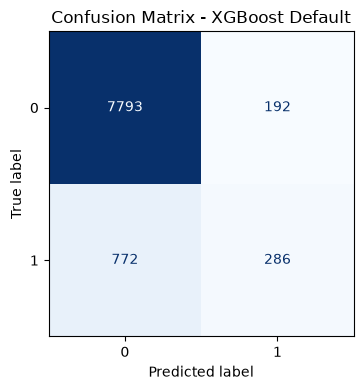

Logged MLflow run: 12e014f343df4cffbb41defea476bbee


,accuracy,precision,recall,f1,roc_auc,brier_score,run_id,run_name
0,0.893398,0.598326,0.270321,0.372396,0.790968,0.08322,12e014f343df4cffbb41defea476bbee,xgboost_default_20260721_140439


In [9]:
run_name = f"xgboost_default_{datetime.now().strftime('%Y%m%d_%H%M%S')}"

model = XGBClassifier(**xgb_params)

params_to_log = {
    param_name: param_value
    for param_name, param_value in xgb_params.items()
    if param_value is not None
}

REPORTS_DIR.mkdir(parents=True, exist_ok=True)

with mlflow.start_run(run_name=run_name) as run:
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    metrics = evaluate_model(y_test, y_pred, y_proba)

    mlflow.log_params(params_to_log)
    mlflow.log_metrics(metrics)

    mlflow.set_tags(
        {
            "project": "bank-marketing",
            "stage": "model_development",
            "model_family": "xgboost",
            "model_variant": "default",
            "data_split": "processed_train_test_from_notebook_03",
            "source_notebook": "07_mlflow_experiment_tracking.ipynb",
        }
    )

    metrics_path = REPORTS_DIR / "07_mlflow_xgboost_metrics.csv"
    predictions_path = REPORTS_DIR / "07_mlflow_xgboost_predictions.csv"
    confusion_matrix_path = REPORTS_DIR / "07_mlflow_confusion_matrix.png"

    metrics_table = pd.DataFrame(
        [
            {
                **metrics,
                "run_id": run.info.run_id,
                "run_name": run_name,
            }
        ]
    )
    metrics_table.to_csv(metrics_path, index=False)

    predictions = test_metadata.copy()
    predictions["y_true"] = y_test.to_numpy()
    predictions["y_pred"] = y_pred
    predictions["subscription_probability"] = y_proba
    predictions.to_csv(predictions_path, index=False)

    fig, ax = plt.subplots(figsize=(5, 4))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        cmap="Blues",
        ax=ax,
        colorbar=False,
    )

    ax.set_title("Confusion Matrix - XGBoost Default")
    fig.tight_layout()
    fig.savefig(confusion_matrix_path, dpi=150)
    plt.show()

    mlflow.log_artifact(metrics_path, artifact_path="reports")
    mlflow.log_artifact(predictions_path, artifact_path="reports")
    mlflow.log_artifact(confusion_matrix_path, artifact_path="figures")
    mlflow.xgboost.log_model(model, name="model")

    run_id = run.info.run_id

print(f"Logged MLflow run: {run_id}")
metrics_table

#### Key Observations

- The default XGBoost model was successfully trained and logged as an MLflow run.
- The run reproduced the performance obtained in the previous modeling notebooks, with an F1-score of 0.3724 and a ROC AUC of 0.7910.
- The model achieved high overall accuracy, but this result must be interpreted carefully because the target variable is highly imbalanced.
- Precision was 0.5983, meaning that approximately 60% of the clients predicted as subscribers actually subscribed.
- Recall was 0.2703, showing that the model identified only around 27% of all actual subscribers.
- The confusion matrix contained 7,793 true negatives, 192 false positives, 772 false negatives, and 286 true positives.
- The large number of false negatives confirms that detecting the positive subscription class remains the main model limitation.
- MLflow connected the model parameters, evaluation metrics, prediction file, confusion matrix, and trained model artifact to the same unique run.
- The manually saved model files in `models/` were not overwritten. The MLflow model was stored separately as an artifact of this run.
- Re-executing the cell creates a new timestamped MLflow run, allowing different executions to be compared without replacing previous runs.

## 8. Inspect Runs from Python

The UI is usually the most convenient way to inspect experiments. We can also query runs directly from Python, which is useful for reports or later automation.

In [11]:
experiment = mlflow.get_experiment_by_name("bank-marketing")
runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["metrics.f1 DESC"],
)

columns_to_show = [
    "run_id",
    "tags.mlflow.runName",
    "tags.model_variant",
    "metrics.accuracy",
    "metrics.precision",
    "metrics.recall",
    "metrics.f1",
    "metrics.roc_auc",
    "metrics.brier_score",
]

runs[columns_to_show].head()

,run_id,tags.mlflow.runName,tags.model_variant,metrics.accuracy,metrics.precision,metrics.recall,metrics.f1,metrics.roc_auc,metrics.brier_score
0,12e014f343df4cffbb41defea476bbee,xgboost_default_20260721_140439,default,0.893398,0.598326,0.270321,0.372396,0.790968,0.08322


#### Key Observations

- The `bank-marketing` experiment was successfully queried directly from Python.
- MLflow returned the stored run information as a pandas DataFrame without retraining or modifying the model.
- Runs are ordered by F1-score, which makes it possible to identify the strongest execution according to the primary evaluation metric.
- The retrieved information includes the unique run ID, run name, model variant, and the six core classification metrics.
- The results match the evaluation values recorded when the default XGBoost model was trained.
- Programmatic run queries can later support automated model comparison, reporting, and model-selection workflows.

## 9. From Tracking to Artifact Management

MLflow helps us move from scattered notebook outputs to a structured experiment record.

In this notebook, the model is logged as an MLflow model artifact. That means MLflow stores not only the serialized model, but also metadata about how it can be loaded again. This becomes important when we later serve the model through an API.

For a larger production setup, we would usually add stronger model governance: model versions, approval states, deployment environments, owners, and rollback rules. For this course project, the important step is the shift from manual files to traceable model artifacts.

In [12]:
model_uri = f"runs:/{run_id}/model"
loaded_model = mlflow.xgboost.load_model(model_uri)
loaded_predictions = loaded_model.predict(X_test.head(5))

print("Model URI:", model_uri)
print("Predictions for first five test rows:", loaded_predictions.tolist())

Model URI: runs:/12e014f343df4cffbb41defea476bbee/model
Predictions for first five test rows: [0, 0, 0, 0, 0]


#### Key Observations

- The trained XGBoost model was successfully reloaded from its MLflow run using the model URI.
- The artifact download progress indicates that MLflow retrieved the serialized model and its associated metadata.
- Reloading the model did not retrain or modify it, it reused the artifact stored in the previous run.
- The reloaded model successfully generated predictions for the first five observations in the test set.
- This confirms that the logged model artifact is reusable and can later support inference, deployment, or API serving.

## 10. Reflection

MLflow does not make a weak evaluation setup better. It records what happened. The quality of the experiment still depends on good data preparation, realistic validation, meaningful metrics, clear business assumptions, and a consistent evaluation function.

The practical benefit is traceability. If a result is discussed later, we can inspect the parameters, metrics, artifacts, and model version that produced it. This is the bridge from exploratory notebook work toward a reproducible ML workflow.

In this notebook, MLflow runs locally. That is useful for learning and for small individual projects. In a team setting, the tracking server is usually set up centrally so that everyone can access the same experiments, compare runs, and avoid separate local experiment histories. A central setup also makes it easier to connect experiment tracking with model registry, review processes, and deployment decisions.